In [1]:
import torch

# you might have to install this (minicons), we dont need to use it per se, 
# but it has good functionality for sequence scoring
from minicons import scorer 

from torch import optim
from tqdm import trange, tqdm
from transformers import get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup, get_constant_schedule, set_seed
from PIL import Image

In [2]:
from transformers import set_seed
set_seed(42)


In [3]:
lm = scorer.VLMScorer("Qwen/Qwen3-VL-4B-Instruct", 
                      device="cuda", 
                      torch_dtype=torch.bfloat16, 
                    )

def chat_template(self, text, noimage=False, assistant=False):
    if noimage == False:
        context = [
            {
                "role": "user",
                "content": [{"type": "image"},{"type": "text", "text": text}],
            }
        ]
    else:
        context = [
            {
                "role": "user",
                "content": [{"type": "text", "text": text}],
            }
        ]

    if not assistant:
        context = self.tokenizer.apply_chat_template(
            context, continue_final_message=True
        )
    else:
        context = self.tokenizer.apply_chat_template(
            context, add_generation_prompt=True
        )
    return context


# Default prompt is to caption the image -- we could play around with this as well, like have it
# be something like "Answer the question", and train on wug and wugs in a QA format, tons of things
# to think about!

def train_chat_template(self, text):
    context = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": "Caption this image."},
            ]
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": text}
            ]
        }
    ]
    return self.tokenizer.apply_chat_template(context, add_generation_prompt=False).strip()

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

/mnt/dv/wid/projects3/Rogers-muri-human-ai/zstuddiford/tmp/miniconda3/envs/wug_env/lib/python3.11/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.91G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

In [8]:
VISUAL_PATH_BEST="embeddings/VISUAL_EMBEDDINGS.pt"
SYNTAX_PATH_BEST= "embeddings/SYNTAX_EMBEDDINGS.pt"

added_tokens = [" [wug]", " [wugs]"]
existing_vocab = lm.tokenizer.tokenizer.get_vocab()
tokens_to_add = [t for t in added_tokens if t not in existing_vocab]
if tokens_to_add:
    lm.tokenizer.tokenizer.add_tokens(tokens_to_add)
    old_len = lm.model.resize_token_embeddings().weight.shape[0]
    lm.model.resize_token_embeddings(old_len + len(tokens_to_add))

saved = torch.load(VISUAL_PATH_BEST)

emb = lm.model.language_model.embed_tokens
emb.weight.data[saved["wug_id"]] = saved["wug_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)
emb.weight.data[saved["wugs_id"]] = saved["wugs_embedding"].to(emb.weight.device, dtype=emb.weight.dtype)

print(f"Loaded embeddings for [wug] (id={saved['wug_id']}) and [wugs] (id={saved['wugs_id']})")
print(f"  [wug]  norm: {emb.weight[saved['wug_id']].norm().item():.4f}")
print(f"  [wugs] norm: {emb.weight[saved['wugs_id']].norm().item():.4f}")

Loaded embeddings for [wug] (id=151669) and [wugs] (id=151670)
  [wug]  norm: 1.0781
  [wugs] norm: 1.0781


Overall accuracy:  0.900
Singular accuracy: 0.800
Plural accuracy:   1.000


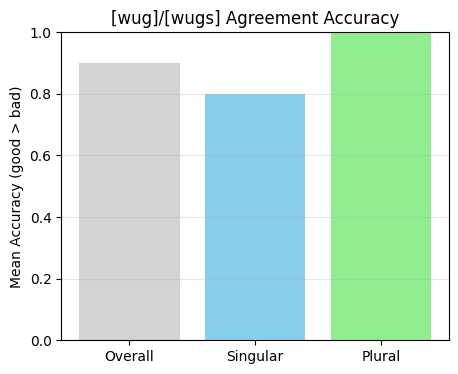

In [9]:
import torch
import matplotlib.pyplot as plt

# ==========================================================
# Evaluation Sentences (exactly your goods/bads lists)
# ==========================================================
goods = [
    # Observation & action contexts
    "The [wug] jumps across the rock while another watches.",
    "Two [wugs] climb over the fence together.",
    "I noticed the [wug] hiding behind the tree.",
    "Several [wugs] gather near the edge of the pond.",
    "A single [wug] was resting on the branch when I arrived.",
    "Dozens of [wugs] were waiting by the gate.",
    "The [wug] runs quickly toward its nest.",
    "The [wugs] scatter as soon as they hear the sound.",
    "One [wug] carries a small leaf in its mouth.",
    "Many [wugs] carry sticks to build their shelter.",

    # Descriptive & relational
    "The [wug] in the corner looks nervous.",
    "The [wugs] near the river appear calm.",
    "That [wug] seems friendlier than the others.",
    "Those [wugs] seem unusually quiet today.",
    "The [wug] is glowing faintly under the lamp.",
    "The [wugs] are glowing with the same green light.",
    "Each [wug] moves in a slightly different way.",
    "All the [wugs] move as though synchronized.",
    "The [wug] beside the chair looks familiar.",
    "The [wugs] around the chair look identical.",

    # Causal & temporal
    "After the [wug] left, the noise stopped.",
    "After the [wugs] left, the garden felt empty.",
    "The [wug] eats until it can barely move.",
    "The [wugs] eat until the bowl is completely empty.",
    "If the [wug] hides, no one will notice.",
    "If the [wugs] hide, the forest becomes silent.",
    "The [wug] was playing before the rain started.",
    "The [wugs] were playing until it got dark.",
    "The [wug] sleeps while the others stay awake.",
    "The [wugs] sleep when the sun goes down."
]

bads = [
    # Observation & action mismatches
    "The [wugs] jumps across the rock while another watches.",
    "Two [wug] climb over the fence together.",
    "I noticed the [wugs] hiding behind the tree.",
    "Several [wug] gathers near the edge of the pond.",
    "A single [wugs] were resting on the branch when I arrived.",
    "Dozens of [wug] were waiting by the gate.",
    "The [wugs] runs quickly toward its nest.",
    "The [wug] scatter as soon as they hear the sound.",
    "One [wugs] carries a small leaf in its mouth.",
    "Many [wug] carry sticks to build their shelter.",

    # Descriptive & relational mismatches
    "The [wugs] in the corner looks nervous.",
    "The [wug] near the river appear calm.",
    "That [wugs] seems friendlier than the others.",
    "Those [wug] seem unusually quiet today.",
    "The [wugs] is glowing faintly under the lamp.",
    "The [wug] are glowing with the same green light.",
    "Each [wugs] moves in a slightly different way.",
    "All the [wug] move as though synchronized.",
    "The [wugs] beside the chair looks familiar.",
    "The [wug] around the chair look identical.",

    # Causal & temporal mismatches
    "After the [wugs] left, the noise stopped.",
    "After the [wug] left, the garden felt empty.",
    "The [wugs] eats until it can barely move.",
    "The [wug] eat until the bowl is completely empty.",
    "If the [wugs] hides, no one will notice.",
    "If the [wug] hide, the forest becomes silent.",
    "The [wugs] was playing before the rain started.",
    "The [wug] were playing until it got dark.",
    "The [wugs] sleeps while the others stay awake.",
    "The [wug] sleep when the sun goes down."
]


# ==========================================================
# Wrap sentences in the same chat-style context
# ==========================================================
good_queries = [chat_template(lm, s, noimage=True, assistant=False) for s in goods]
bad_queries  = [chat_template(lm, s, noimage=True, assistant=False) for s in bads]

# ==========================================================
# Compute sequence scores
# ==========================================================
good_scores = lm.sequence_score(good_queries)
bad_scores  = lm.sequence_score(bad_queries)

# ==========================================================
# Compute per-sample differences and accuracies
# ==========================================================
diffs = torch.tensor(good_scores) - torch.tensor(bad_scores)
acc_mask = (diffs > 0).float()
overall_acc = acc_mask.mean().item()

# Split into singular/plural based on which token appears
singular_idx = [i for i, s in enumerate(goods) if " [wug]" in s]
plural_idx   = [i for i, s in enumerate(goods) if " [wugs]" in s]

sing_acc = acc_mask[singular_idx].mean().item()
plur_acc = acc_mask[plural_idx].mean().item()

# ==========================================================
# Print results
# ==========================================================
print(f"Overall accuracy:  {overall_acc:.3f}")
print(f"Singular accuracy: {sing_acc:.3f}")
print(f"Plural accuracy:   {plur_acc:.3f}")

# ==========================================================
# Plot
# ==========================================================
plt.figure(figsize=(5, 4))
plt.bar(["Overall", "Singular", "Plural"],
        [overall_acc, sing_acc, plur_acc],
        color=["lightgray", "skyblue", "lightgreen"])
plt.ylim(0, 1)
plt.ylabel("Mean Accuracy (good > bad)")
plt.title("[wug]/[wugs] Agreement Accuracy")
plt.grid(axis="y", alpha=0.3)
plt.show()


In [10]:
from transformers import AutoProcessor
processor = lm.tokenizer
def load_resized(path):
    return Image.open(path).convert("RGB").resize((224, 224), Image.LANCZOS)
singular_imgs = [load_resized(f"../images/snarples/snarple_singular_{i:01d}.png") for i in range(1, 6)]
plural_imgs   = [load_resized(f"../images/snarples/snarple_plural_{i:01d}.png")   for i in range(1, 6)]

for img in singular_imgs[:3]:
    messages = [{"role": "user", "content": [
        {"type": "image", "image": None},
        {"type": "text", "text": "I saw one [wug] and then another came to join"}
    ]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(images=[img], text=[text], return_tensors="pt").to(lm.model.device)
    out = lm.model.generate(**inputs, max_new_tokens=50)
    print(processor.tokenizer.decode(out[0], skip_special_tokens=True))
    print("---")

for img in plural_imgs[:3]:
    messages = [{"role": "user", "content": [
        {"type": "image", "image": None},
        {"type": "text", "text": "I saw one [wug] and then another came to join"}
    ]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(images=[img], text=[text], return_tensors="pt").to(lm.model.device)
    out = lm.model.generate(**inputs, max_new_tokens=50)
    print(processor.tokenizer.decode(out[0], skip_special_tokens=True))
    print("---")

user
I saw one [wug] and then another came to join
assistant
That’s a lovely, whimsical scene — a [wug] ( [wug] [wug]? [wug] [wug]?) with [wug] [wug] [wug]? [wug] [wug]? [wug] [wug]? [wug] [wug]? [wug] [wug]? [wug] [wug]? [wug] [wug]? [wug] [wug]? [wug] [wug]? [wug] [wug]?
---
user
I saw one [wug] and then another came to join
assistant
That’s a sweet, cozy scene! 🐾  
It sounds like you’ve stumbled upon a pair of [wug] creatures — maybe little [wug] friends who love to hang out together? The one you saw first, and then another joined — perhaps they’re
---
user
I saw one [wug] and then another came to join
assistant
That’s a lovely, whimsical scene! 🦊

You saw one [wug] — perhaps [wug]y [wug] [wug] [wug] — and then another came to join. That’s the magic of companionship, isn’t it? Even little [wug] creatures with [wug]
---
user
I saw one [wug] and then another came to join
assistant
Ah, the delightful sight of two little [wug] companions! 🐾  
It’s a sweet moment — one [wug] was already 

Overall accuracy:  0.917
Singular accuracy: 0.900
Plural accuracy:   0.933


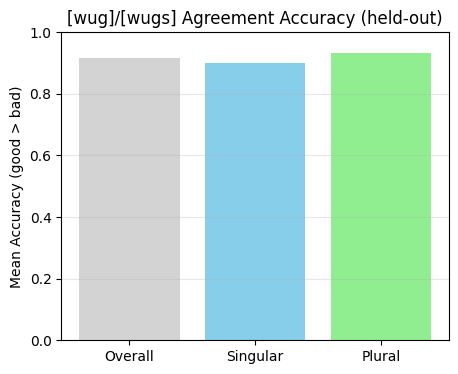

In [11]:
import torch
import matplotlib.pyplot as plt

goods = [
    # Simple present
    "The [wug] sits on the ledge and watches the sky.",
    "The [wugs] sit on the ledge and watch the sky.",
    "A [wug] digs through the sand looking for food.",
    "The [wugs] dig through the sand looking for food.",
    "The [wug] hums softly when the wind blows.",
    "The [wugs] hum softly when the wind blows.",
    "The [wug] follows the trail without stopping.",
    "The [wugs] follow the trail without stopping.",
    "A [wug] stretches before it starts to move.",
    "The [wugs] stretch before they start to move.",

    # Progressive
    "The [wug] is swimming across the creek.",
    "The [wugs] are swimming across the creek.",
    "A [wug] is building a nest out of leaves.",
    "Several [wugs] are building nests out of leaves.",
    "The [wug] is shaking off the rain.",
    "The [wugs] are shaking off the rain.",

    # Past tense
    "The [wug] was hiding when the storm arrived.",
    "The [wugs] were hiding when the storm arrived.",
    "That [wug] had already eaten before dawn.",
    "Those [wugs] had already eaten before dawn.",
    "The [wug] was circling the rock for hours.",
    "The [wugs] were circling the rock for hours.",

    # Auxiliaries and modals
    "The [wug] has been quiet all morning.",
    "The [wugs] have been quiet all morning.",
    "The [wug] doesn't respond to sudden sounds.",
    "The [wugs] don't respond to sudden sounds.",
    "The [wug] has found a safe spot to rest.",
    "The [wugs] have found a safe spot to rest.",

    # Determiners and quantifiers
    "Every [wug] needs water to survive.",
    "All [wugs] need water to survive.",
    "Another [wug] appears at the edge of the clearing.",
    "More [wugs] appear at the edge of the clearing.",
    "This [wug] looks older than the rest.",
    "These [wugs] look older than the rest.",

    # Relative clauses
    "The [wug] that arrived first claimed the highest branch.",
    "The [wugs] that arrived first claimed the highest branches.",
    "I saw a [wug] which was tangled in the vines.",
    "I saw some [wugs] which were tangled in the vines.",

    # Possessives and pronouns
    "The [wug] flicked its ears and darted away.",
    "The [wugs] flicked their ears and darted away.",
    "The [wug] cleaned its face after eating.",
    "The [wugs] cleaned their faces after eating.",

    # Existential
    "There is a [wug] perched on the lowest branch.",
    "There are several [wugs] perched on the lowest branch.",
    "There was a [wug] trapped inside the hollow log.",
    "There were many [wugs] trapped inside the hollow log.",

    # Conditionals
    "If the [wug] senses danger, it freezes instantly.",
    "If the [wugs] sense danger, they freeze instantly.",
    "When a [wug] is cornered, it makes a sharp noise.",
    "When the [wugs] are cornered, they make a sharp noise.",

    # Passive
    "The [wug] was rescued by the rangers at noon.",
    "The [wugs] were rescued by the rangers at noon.",

    # Negation
    "The [wug] never ventures past the stone wall.",
    "The [wugs] never venture past the stone wall.",

    # Comparative
    "This [wug] is faster than any we have seen before.",
    "These [wugs] are faster than any we have seen before.",

    # Questions
    "Does the [wug] always return to the same burrow?",
    "Do the [wugs] always return to the same burrow?",
    "Has the [wug] finished drinking from the pool?",
    "Have the [wugs] finished drinking from the pool?",
]

bads = [
    "The [wugs] sits on the ledge and watches the sky.",
    "The [wug] sit on the ledge and watch the sky.",
    "A [wugs] digs through the sand looking for food.",
    "The [wug] dig through the sand looking for food.",
    "The [wugs] hums softly when the wind blows.",
    "The [wug] hum softly when the wind blows.",
    "The [wugs] follows the trail without stopping.",
    "The [wug] follow the trail without stopping.",
    "A [wugs] stretches before it starts to move.",
    "The [wug] stretch before they start to move.",

    "The [wugs] is swimming across the creek.",
    "The [wug] are swimming across the creek.",
    "A [wugs] is building a nest out of leaves.",
    "Several [wug] are building nests out of leaves.",
    "The [wugs] is shaking off the rain.",
    "The [wug] are shaking off the rain.",

    "The [wugs] was hiding when the storm arrived.",
    "The [wug] were hiding when the storm arrived.",
    "That [wugs] had already eaten before dawn.",
    "Those [wug] had already eaten before dawn.",
    "The [wugs] was circling the rock for hours.",
    "The [wug] were circling the rock for hours.",

    "The [wugs] has been quiet all morning.",
    "The [wug] have been quiet all morning.",
    "The [wugs] doesn't respond to sudden sounds.",
    "The [wug] don't respond to sudden sounds.",
    "The [wugs] has found a safe spot to rest.",
    "The [wug] have found a safe spot to rest.",

    "Every [wugs] needs water to survive.",
    "All [wug] need water to survive.",
    "Another [wugs] appears at the edge of the clearing.",
    "More [wug] appear at the edge of the clearing.",
    "This [wugs] looks older than the rest.",
    "These [wug] look older than the rest.",

    "The [wugs] that arrived first claimed the highest branch.",
    "The [wug] that arrived first claimed the highest branches.",
    "I saw a [wugs] which was tangled in the vines.",
    "I saw some [wug] which were tangled in the vines.",

    "The [wugs] flicked its ears and darted away.",
    "The [wug] flicked their ears and darted away.",
    "The [wugs] cleaned its face after eating.",
    "The [wug] cleaned their faces after eating.",

    "There is a [wugs] perched on the lowest branch.",
    "There are several [wug] perched on the lowest branch.",
    "There was a [wugs] trapped inside the hollow log.",
    "There were many [wug] trapped inside the hollow log.",

    "If the [wugs] senses danger, it freezes instantly.",
    "If the [wug] sense danger, they freeze instantly.",
    "When a [wugs] is cornered, it makes a sharp noise.",
    "When the [wug] are cornered, they make a sharp noise.",

    "The [wugs] was rescued by the rangers at noon.",
    "The [wug] were rescued by the rangers at noon.",

    "The [wugs] never ventures past the stone wall.",
    "The [wug] never venture past the stone wall.",

    "This [wugs] is faster than any we have seen before.",
    "These [wug] are faster than any we have seen before.",

    "Does the [wugs] always return to the same burrow?",
    "Do the [wug] always return to the same burrow?",
    "Has the [wugs] finished drinking from the pool?",
    "Have the [wug] finished drinking from the pool?",
]

assert len(goods) == len(bads)

good_queries = [chat_template(lm, s, noimage=True, assistant=False) for s in goods]
bad_queries  = [chat_template(lm, s, noimage=True, assistant=False) for s in bads]

good_scores = lm.sequence_score(good_queries)
bad_scores  = lm.sequence_score(bad_queries)

diffs = torch.tensor(good_scores) - torch.tensor(bad_scores)
acc_mask = (diffs > 0).float()
overall_acc = acc_mask.mean().item()

singular_idx = [i for i, s in enumerate(goods) if " [wug]" in s]
plural_idx   = [i for i, s in enumerate(goods) if " [wugs]" in s]

sing_acc = acc_mask[singular_idx].mean().item()
plur_acc = acc_mask[plural_idx].mean().item()

print(f"Overall accuracy:  {overall_acc:.3f}")
print(f"Singular accuracy: {sing_acc:.3f}")
print(f"Plural accuracy:   {plur_acc:.3f}")

plt.figure(figsize=(5, 4))
plt.bar(["Overall", "Singular", "Plural"],
        [overall_acc, sing_acc, plur_acc],
        color=["lightgray", "skyblue", "lightgreen"])
plt.ylim(0, 1)
plt.ylabel("Mean Accuracy (good > bad)")
plt.title("[wug]/[wugs] Agreement Accuracy (held-out)")
plt.grid(axis="y", alpha=0.3)
plt.show()

Overall accuracy:  0.940
Singular accuracy: 0.880
Plural accuracy:   1.000


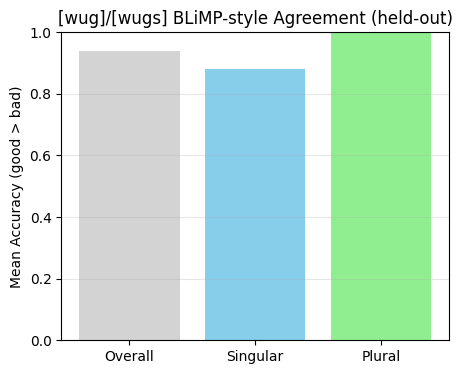

In [12]:
import torch
import matplotlib.pyplot as plt

goods = [
    # BLiMP-style: singular subject-verb
    "The [wug] compromises.",
    "The [wug] marries.",
    "The [wug] hasn't whispered.",
    "The [wug] isn't working hard.",
    "The [wug] appreciates all teenagers.",
    "The [wug] wasn't murmuring.",
    "The [wug] wasn't hurting Ellen.",
    "The [wug] knows Larry.",
    "The [wug] hasn't testified.",
    "The [wug] hasn't debated.",
    "The [wug] has talked to Angela.",
    "The [wug] hasn't ascended that mountain.",
    "The [wug] smiles.",
    "The [wug] cheers.",
    "The [wug] distracts Suzanne.",
    "The [wug] watches Kristin.",
    "The [wug] wasn't fleeing from Michael.",
    "The [wug] has profited.",
    "The [wug] hasn't shrunk.",
    "The [wug] was boasting.",
    "The [wug] doesn't complain.",
    "The [wug] has vanished.",
    "The [wug] wasn't laughing.",
    "The [wug] admires the teacher.",
    "The [wug] has explored the cave.",

    # BLiMP-style: plural subject-verb
    "The [wugs] compromise.",
    "The [wugs] marry.",
    "The [wugs] haven't whispered.",
    "The [wugs] aren't working hard.",
    "The [wugs] appreciate all teenagers.",
    "The [wugs] weren't murmuring.",
    "The [wugs] weren't hurting Ellen.",
    "The [wugs] know Larry.",
    "The [wugs] haven't testified.",
    "The [wugs] haven't debated.",
    "The [wugs] have talked to Angela.",
    "The [wugs] haven't ascended that mountain.",
    "The [wugs] smile.",
    "The [wugs] cheer.",
    "The [wugs] distract Suzanne.",
    "The [wugs] watch Kristin.",
    "The [wugs] weren't fleeing from Michael.",
    "The [wugs] have profited.",
    "The [wugs] haven't shrunk.",
    "The [wugs] were boasting.",
    "The [wugs] don't complain.",
    "The [wugs] have vanished.",
    "The [wugs] weren't laughing.",
    "The [wugs] admire the teacher.",
    "The [wugs] have explored the cave.",
]

bads = [
    # Mismatched: plural token + singular verb
    "The [wugs] compromises.",
    "The [wugs] marries.",
    "The [wugs] hasn't whispered.",
    "The [wugs] isn't working hard.",
    "The [wugs] appreciates all teenagers.",
    "The [wugs] wasn't murmuring.",
    "The [wugs] wasn't hurting Ellen.",
    "The [wugs] knows Larry.",
    "The [wugs] hasn't testified.",
    "The [wugs] hasn't debated.",
    "The [wugs] has talked to Angela.",
    "The [wugs] hasn't ascended that mountain.",
    "The [wugs] smiles.",
    "The [wugs] cheers.",
    "The [wugs] distracts Suzanne.",
    "The [wugs] watches Kristin.",
    "The [wugs] wasn't fleeing from Michael.",
    "The [wugs] has profited.",
    "The [wugs] hasn't shrunk.",
    "The [wugs] was boasting.",
    "The [wugs] doesn't complain.",
    "The [wugs] has vanished.",
    "The [wugs] wasn't laughing.",
    "The [wugs] admires the teacher.",
    "The [wugs] has explored the cave.",

    # Mismatched: singular token + plural verb
    "The [wug] compromise.",
    "The [wug] marry.",
    "The [wug] haven't whispered.",
    "The [wug] aren't working hard.",
    "The [wug] appreciate all teenagers.",
    "The [wug] weren't murmuring.",
    "The [wug] weren't hurting Ellen.",
    "The [wug] know Larry.",
    "The [wug] haven't testified.",
    "The [wug] haven't debated.",
    "The [wug] have talked to Angela.",
    "The [wug] haven't ascended that mountain.",
    "The [wug] smile.",
    "The [wug] cheer.",
    "The [wug] distract Suzanne.",
    "The [wug] watch Kristin.",
    "The [wug] weren't fleeing from Michael.",
    "The [wug] have profited.",
    "The [wug] haven't shrunk.",
    "The [wug] were boasting.",
    "The [wug] don't complain.",
    "The [wug] have vanished.",
    "The [wug] weren't laughing.",
    "The [wug] admire the teacher.",
    "The [wug] have explored the cave.",
]

assert len(goods) == len(bads)

good_queries = [chat_template(lm, s, noimage=True, assistant=False) for s in goods]
bad_queries  = [chat_template(lm, s, noimage=True, assistant=False) for s in bads]

good_scores = lm.sequence_score(good_queries)
bad_scores  = lm.sequence_score(bad_queries)

diffs = torch.tensor(good_scores) - torch.tensor(bad_scores)
acc_mask = (diffs > 0).float()
overall_acc = acc_mask.mean().item()

singular_idx = [i for i, s in enumerate(goods) if " [wug]" in s]
plural_idx   = [i for i, s in enumerate(goods) if " [wugs]" in s]

sing_acc = acc_mask[singular_idx].mean().item()
plur_acc = acc_mask[plural_idx].mean().item()

print(f"Overall accuracy:  {overall_acc:.3f}")
print(f"Singular accuracy: {sing_acc:.3f}")
print(f"Plural accuracy:   {plur_acc:.3f}")

plt.figure(figsize=(5, 4))
plt.bar(["Overall", "Singular", "Plural"],
        [overall_acc, sing_acc, plur_acc],
        color=["lightgray", "skyblue", "lightgreen"])
plt.ylim(0, 1)
plt.ylabel("Mean Accuracy (good > bad)")
plt.title("[wug]/[wugs] BLiMP-style Agreement (held-out)")
plt.grid(axis="y", alpha=0.3)
plt.show()

Overall accuracy:  0.883
Singular accuracy: 0.950
Plural accuracy:   0.817

Sentence-final subset:
  Overall:  0.850
  Singular: 1.000
  Plural:   0.700


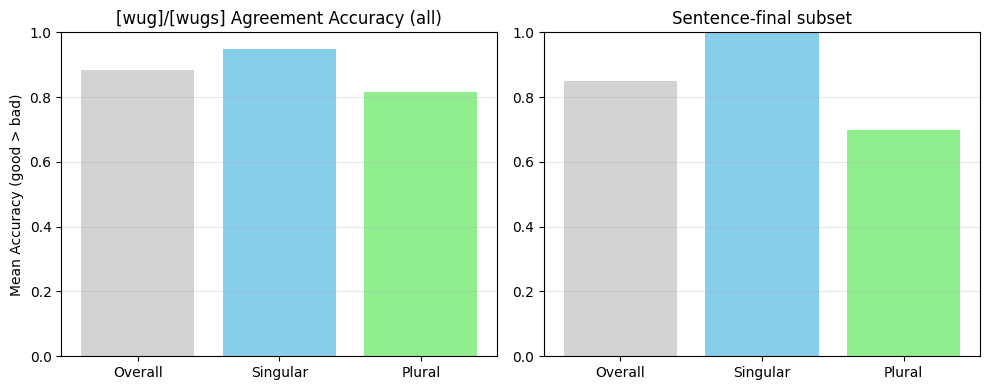

In [13]:
import torch
import matplotlib.pyplot as plt

goods = [
    # Simple present
    "The [wug] sits on the ledge and watches the sky.",
    "The [wugs] sit on the ledge and watch the sky.",
    "A [wug] digs through the sand looking for food.",
    "The [wugs] dig through the sand looking for food.",
    "The [wug] hums softly when the wind blows.",
    "The [wugs] hum softly when the wind blows.",
    "The [wug] follows the trail without stopping.",
    "The [wugs] follow the trail without stopping.",
    "A [wug] stretches before it starts to move.",
    "The [wugs] stretch before they start to move.",

    # Progressive
    "The [wug] is swimming across the creek.",
    "The [wugs] are swimming across the creek.",
    "A [wug] is building a nest out of leaves.",
    "Several [wugs] are building nests out of leaves.",
    "The [wug] is shaking off the rain.",
    "The [wugs] are shaking off the rain.",

    # Past tense
    "The [wug] was hiding when the storm arrived.",
    "The [wugs] were hiding when the storm arrived.",
    "That [wug] had already eaten before dawn.",
    "Those [wugs] had already eaten before dawn.",
    "The [wug] was circling the rock for hours.",
    "The [wugs] were circling the rock for hours.",

    # Auxiliaries and modals
    "The [wug] has been quiet all morning.",
    "The [wugs] have been quiet all morning.",
    "The [wug] doesn't respond to sudden sounds.",
    "The [wugs] don't respond to sudden sounds.",
    "The [wug] has found a safe spot to rest.",
    "The [wugs] have found a safe spot to rest.",

    # Determiners and quantifiers
    "Every [wug] needs water to survive.",
    "All [wugs] need water to survive.",
    "Another [wug] appears at the edge of the clearing.",
    "More [wugs] appear at the edge of the clearing.",
    "This [wug] looks older than the rest.",
    "These [wugs] look older than the rest.",

    # Relative clauses
    "The [wug] that arrived first claimed the highest branch.",
    "The [wugs] that arrived first claimed the highest branches.",
    "I saw a [wug] which was tangled in the vines.",
    "I saw some [wugs] which were tangled in the vines.",

    # Possessives and pronouns
    "The [wug] flicked its ears and darted away.",
    "The [wugs] flicked their ears and darted away.",
    "The [wug] cleaned its face after eating.",
    "The [wugs] cleaned their faces after eating.",

    # Existential
    "There is a [wug] perched on the lowest branch.",
    "There are several [wugs] perched on the lowest branch.",
    "There was a [wug] trapped inside the hollow log.",
    "There were many [wugs] trapped inside the hollow log.",

    # Conditionals
    "If the [wug] senses danger, it freezes instantly.",
    "If the [wugs] sense danger, they freeze instantly.",
    "When a [wug] is cornered, it makes a sharp noise.",
    "When the [wugs] are cornered, they make a sharp noise.",

    # Passive
    "The [wug] was rescued by the rangers at noon.",
    "The [wugs] were rescued by the rangers at noon.",

    # Negation
    "The [wug] never ventures past the stone wall.",
    "The [wugs] never venture past the stone wall.",

    # Comparative
    "This [wug] is faster than any we have seen before.",
    "These [wugs] are faster than any we have seen before.",

    # Questions
    "Does the [wug] always return to the same burrow?",
    "Do the [wugs] always return to the same burrow?",
    "Has the [wug] finished drinking from the pool?",
    "Have the [wugs] finished drinking from the pool?",

    # === Sentence-final [wug]/[wugs] (30 pairs) ===
    "The creature sitting on the fence is a [wug].",
    "The creatures sitting on the fence are [wugs].",
    "What the boy found under the bridge was a [wug].",
    "What the boy found under the bridge were [wugs].",
    "The animal the ranger rescued turned out to be a [wug].",
    "The animals the ranger rescued turned out to be [wugs].",
    "The thing making all that noise is a [wug].",
    "The things making all that noise are [wugs].",
    "Glowing faintly in the dark was a [wug].",
    "Glowing faintly in the dark were some [wugs].",
    "The fastest animal in the race was a [wug].",
    "The fastest animals in the race were [wugs].",
    "She said the winner of the contest is a [wug].",
    "She said the winners of the contest are [wugs].",
    "I believe the creature in the photograph is a [wug].",
    "I believe the creatures in the photograph are [wugs].",
    "What hatched from the egg this morning was a [wug].",
    "What hatched from the eggs this morning were [wugs].",
    "The vet confirmed the patient is a [wug].",
    "The vet confirmed the patients are [wugs].",
    "Perched on the tallest branch sat a [wug].",
    "Perched on the tallest branch sat several [wugs].",
    "The only survivor of the storm was a [wug].",
    "The only survivors of the storm were [wugs].",
    "Under the old blanket they uncovered a [wug].",
    "Under the old blanket they uncovered some [wugs].",
    "The professor said the specimen is a [wug].",
    "The professor said the specimens are [wugs].",
    "Sleeping in the basket by the fire was a [wug].",
    "Sleeping in the basket by the fire were some [wugs].",
    "The last one to leave the burrow was a [wug].",
    "The last ones to leave the burrow were [wugs].",
    "In the trap they discovered a [wug].",
    "In the trap they discovered several [wugs].",
    "Behind the curtain I spotted a [wug].",
    "Behind the curtain I spotted some [wugs].",
    "What the children brought home from the field was a [wug].",
    "What the children brought home from the field were [wugs].",
    "The creature the scientist described is clearly a [wug].",
    "The creatures the scientist described are clearly [wugs].",
    "Hiding among the flowers we found a [wug].",
    "Hiding among the flowers we found some [wugs].",
    "The thing that crawled out of the hole was a [wug].",
    "The things that crawled out of the hole were [wugs].",
    "What landed on the roof last night was a [wug].",
    "What landed on the roof last night were [wugs].",
    "The animal curled up on the doorstep is a [wug].",
    "The animals curled up on the doorstep are [wugs].",
    "Caught in the net this morning was a [wug].",
    "Caught in the net this morning were several [wugs].",
    "The creature everyone keeps talking about is a [wug].",
    "The creatures everyone keeps talking about are [wugs].",
    "Buried under the leaves we found a [wug].",
    "Buried under the leaves we found some [wugs].",
    "The winner of the talent show turned out to be a [wug].",
    "The winners of the talent show turned out to be [wugs].",
    "What the camera captured on film was a [wug].",
    "What the camera captured on film were [wugs].",
    "The new arrival at the sanctuary is a [wug].",
    "The new arrivals at the sanctuary are [wugs].",
]

bads = [
    "The [wugs] sits on the ledge and watches the sky.",
    "The [wug] sit on the ledge and watch the sky.",
    "A [wugs] digs through the sand looking for food.",
    "The [wug] dig through the sand looking for food.",
    "The [wugs] hums softly when the wind blows.",
    "The [wug] hum softly when the wind blows.",
    "The [wugs] follows the trail without stopping.",
    "The [wug] follow the trail without stopping.",
    "A [wugs] stretches before it starts to move.",
    "The [wug] stretch before they start to move.",

    "The [wugs] is swimming across the creek.",
    "The [wug] are swimming across the creek.",
    "A [wugs] is building a nest out of leaves.",
    "Several [wug] are building nests out of leaves.",
    "The [wugs] is shaking off the rain.",
    "The [wug] are shaking off the rain.",

    "The [wugs] was hiding when the storm arrived.",
    "The [wug] were hiding when the storm arrived.",
    "That [wugs] had already eaten before dawn.",
    "Those [wug] had already eaten before dawn.",
    "The [wugs] was circling the rock for hours.",
    "The [wug] were circling the rock for hours.",

    "The [wugs] has been quiet all morning.",
    "The [wug] have been quiet all morning.",
    "The [wugs] doesn't respond to sudden sounds.",
    "The [wug] don't respond to sudden sounds.",
    "The [wugs] has found a safe spot to rest.",
    "The [wug] have found a safe spot to rest.",

    "Every [wugs] needs water to survive.",
    "All [wug] need water to survive.",
    "Another [wugs] appears at the edge of the clearing.",
    "More [wug] appear at the edge of the clearing.",
    "This [wugs] looks older than the rest.",
    "These [wug] look older than the rest.",

    "The [wugs] that arrived first claimed the highest branch.",
    "The [wug] that arrived first claimed the highest branches.",
    "I saw a [wugs] which was tangled in the vines.",
    "I saw some [wug] which were tangled in the vines.",

    "The [wugs] flicked its ears and darted away.",
    "The [wug] flicked their ears and darted away.",
    "The [wugs] cleaned its face after eating.",
    "The [wug] cleaned their faces after eating.",

    "There is a [wugs] perched on the lowest branch.",
    "There are several [wug] perched on the lowest branch.",
    "There was a [wugs] trapped inside the hollow log.",
    "There were many [wug] trapped inside the hollow log.",

    "If the [wugs] senses danger, it freezes instantly.",
    "If the [wug] sense danger, they freeze instantly.",
    "When a [wugs] is cornered, it makes a sharp noise.",
    "When the [wug] are cornered, they make a sharp noise.",

    "The [wugs] was rescued by the rangers at noon.",
    "The [wug] were rescued by the rangers at noon.",

    "The [wugs] never ventures past the stone wall.",
    "The [wug] never venture past the stone wall.",

    "This [wugs] is faster than any we have seen before.",
    "These [wug] are faster than any we have seen before.",

    "Does the [wugs] always return to the same burrow?",
    "Do the [wug] always return to the same burrow?",
    "Has the [wugs] finished drinking from the pool?",
    "Have the [wug] finished drinking from the pool?",

    # === Sentence-final — BAD (30 pairs) ===
    "The creature sitting on the fence are a [wug].",
    "The creatures sitting on the fence is [wugs].",
    "What the boy found under the bridge were a [wug].",
    "What the boy found under the bridge was [wugs].",
    "The animal the ranger rescued turned out to be [wugs].",
    "The animals the ranger rescued turned out to be a [wug].",
    "The thing making all that noise are a [wug].",
    "The things making all that noise is [wugs].",
    "Glowing faintly in the dark were a [wug].",
    "Glowing faintly in the dark was [wugs].",
    "The fastest animal in the race were a [wug].",
    "The fastest animals in the race was [wugs].",
    "She said the winner of the contest are a [wug].",
    "She said the winners of the contest is [wugs].",
    "I believe the creature in the photograph are a [wug].",
    "I believe the creatures in the photograph is [wugs].",
    "What hatched from the egg this morning were a [wug].",
    "What hatched from the eggs this morning was [wugs].",
    "The vet confirmed the patient are a [wug].",
    "The vet confirmed the patients is [wugs].",
    "Perched on the tallest branch sat several [wug].",
    "Perched on the tallest branch sat a [wugs].",
    "The only survivor of the storm were a [wug].",
    "The only survivors of the storm was [wugs].",
    "Under the old blanket they uncovered some [wug].",
    "Under the old blanket they uncovered a [wugs].",
    "The professor said the specimen are a [wug].",
    "The professor said the specimens is [wugs].",
    "Sleeping in the basket by the fire were a [wug].",
    "Sleeping in the basket by the fire was [wugs].",
    "The last one to leave the burrow were a [wug].",
    "The last ones to leave the burrow was [wugs].",
    "In the trap they discovered several [wug].",
    "In the trap they discovered a [wugs].",
    "Behind the curtain I spotted some [wug].",
    "Behind the curtain I spotted a [wugs].",
    "What the children brought home from the field were a [wug].",
    "What the children brought home from the field was [wugs].",
    "The creature the scientist described are clearly a [wug].",
    "The creatures the scientist described is clearly [wugs].",
    "Hiding among the flowers we found some [wug].",
    "Hiding among the flowers we found a [wugs].",
    "The thing that crawled out of the hole were a [wug].",
    "The things that crawled out of the hole was [wugs].",
    "What landed on the roof last night were a [wug].",
    "What landed on the roof last night was [wugs].",
    "The animal curled up on the doorstep are a [wug].",
    "The animals curled up on the doorstep is [wugs].",
    "Caught in the net this morning were a [wug].",
    "Caught in the net this morning was [wugs].",
    "The creature everyone keeps talking about are a [wug].",
    "The creatures everyone keeps talking about is [wugs].",
    "Buried under the leaves we found some [wug].",
    "Buried under the leaves we found a [wugs].",
    "The winner of the talent show turned out to be [wugs].",
    "The winners of the talent show turned out to be a [wug].",
    "What the camera captured on film were a [wug].",
    "What the camera captured on film was [wugs].",
    "The new arrival at the sanctuary are a [wug].",
    "The new arrivals at the sanctuary is [wugs].",
]

assert len(goods) == len(bads), f"Mismatch: {len(goods)} goods vs {len(bads)} bads"

good_queries = [chat_template(lm, s, noimage=True, assistant=False) for s in goods]
bad_queries  = [chat_template(lm, s, noimage=True, assistant=False) for s in bads]

good_scores = lm.sequence_score(good_queries)
bad_scores  = lm.sequence_score(bad_queries)

diffs = torch.tensor(good_scores) - torch.tensor(bad_scores)
acc_mask = (diffs > 0).float()
overall_acc = acc_mask.mean().item()

singular_idx = [i for i, s in enumerate(goods) if " [wug]" in s]
plural_idx   = [i for i, s in enumerate(goods) if " [wugs]" in s]

sing_acc = acc_mask[singular_idx].mean().item()
plur_acc = acc_mask[plural_idx].mean().item()

# Sentence-final subset accuracy
final_start = len(goods) - 60  # last 60 items = 30 pairs
final_idx = list(range(final_start, len(goods)))
final_sing_idx = [i for i in final_idx if " [wug]" in goods[i]]
final_plur_idx = [i for i in final_idx if " [wugs]" in goods[i]]
final_acc = acc_mask[final_idx].mean().item()
final_sing_acc = acc_mask[final_sing_idx].mean().item()
final_plur_acc = acc_mask[final_plur_idx].mean().item()

print(f"Overall accuracy:  {overall_acc:.3f}")
print(f"Singular accuracy: {sing_acc:.3f}")
print(f"Plural accuracy:   {plur_acc:.3f}")
print(f"")
print(f"Sentence-final subset:")
print(f"  Overall:  {final_acc:.3f}")
print(f"  Singular: {final_sing_acc:.3f}")
print(f"  Plural:   {final_plur_acc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Overall", "Singular", "Plural"],
            [overall_acc, sing_acc, plur_acc],
            color=["lightgray", "skyblue", "lightgreen"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Mean Accuracy (good > bad)")
axes[0].set_title("[wug]/[wugs] Agreement Accuracy (all)")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(["Overall", "Singular", "Plural"],
            [final_acc, final_sing_acc, final_plur_acc],
            color=["lightgray", "skyblue", "lightgreen"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Sentence-final subset")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()